# Credit Risk Scoring - Exploratory Data Analysis

Este notebook tem como objetivo explorar o conjunto de dados utilizado no projeto de Credit Risk Scoring API. Nesta etapa serão realizadas análises exploratórias, avaliação da qualidade dos dados e levantamento de hipóteses que orientarão a etapa de modelagem.

**Observação:** Todo o código de produção será implementado posteriormente na pasta `src/`. Este notebook é destinado exclusivamente à exploração dos dados e experimentação.

# 1.Imports

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
# from sklearn.feature_selection

# 2. Configurações

In [ ]:
# Reprodutibilidade - 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Caminhos do projeto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cs-training.csv"

# Configurações do Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.2f}".format)

# Configurações dos gráficos
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Ignorar warnings desnecessários
warnings.filterwarnings("ignore")

# 3. Carregamento dos Dados

In [20]:
df_raw = pd.read_csv('../data/raw/cs-training.csv', sep=',')

In [21]:
rename_columns = {
    "Unnamed: 0": "id",
    "SeriousDlqin2yrs": "inadimplente",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacao_credito_rotativo",
    "age": "idade",
    "NumberOfTime30-59DaysPastDueNotWorse": "atrasos_30_59_dias",
    "DebtRatio": "indice_endividamento",
    "MonthlyIncome": "renda_mensal",
    "NumberOfOpenCreditLinesAndLoans": "num_linhas_credito",
    "NumberOfTimes90DaysLate": "atrasos_90_dias_ou_mais",
    "NumberRealEstateLoansOrLines": "num_emprestimos_imobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "atrasos_60_89_dias",
    "NumberOfDependents": "num_dependentes"
}

df_raw = df_raw.rename(columns=rename_columns)

In [22]:
df_raw.head()

,id,inadimplente,utilizacao_credito_rotativo,idade,atrasos_30_59_dias,indice_endividamento,renda_mensal,num_linhas_credito,atrasos_90_dias_ou_mais,num_emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


# 4. Primeiras impressões

In [28]:
df_raw.shape

(150000, 12)

In [30]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            150000 non-null  int64  
 1   inadimplente                  150000 non-null  int64  
 2   utilizacao_credito_rotativo   150000 non-null  float64
 3   idade                         150000 non-null  int64  
 4   atrasos_30_59_dias            150000 non-null  int64  
 5   indice_endividamento          150000 non-null  float64
 6   renda_mensal                  120269 non-null  float64
 7   num_linhas_credito            150000 non-null  int64  
 8   atrasos_90_dias_ou_mais       150000 non-null  int64  
 9   num_emprestimos_imobiliarios  150000 non-null  int64  
 10  atrasos_60_89_dias            150000 non-null  int64  
 11  num_dependentes               146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB


In [ ]:
df_raw.describe()

,id,inadimplente,utilizacao_credito_rotativo,idade,atrasos_30_59_dias,indice_endividamento,renda_mensal,num_linhas_credito,atrasos_90_dias_ou_mais,num_emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


renda mensal possui nans

num_dependentes possui nans

## 4.1 inadimplente

In [ ]:
df_raw['inadimplente'].value_counts()

inadimplente
0    139974
1     10026
Name: count, dtype: int64

- O conjunto apresenta desbalanceamento entre as classes.
- A maioria dos clientes não entrou em inadimplência.
- Esse comportamento é esperado em problemas de crédito, pois instituições financeiras normalmente possuem uma proporção maior de bons pagadores.

Como consequência, métricas como acurácia não serão suficientes para avaliar o modelo, sendo necessário utilizar métricas como ROC-AUC, Precision, Recall, F1-score e KS Statistic.

## 4.2 utilizacao_credito_rotativo

In [43]:
df_raw[df_raw['utilizacao_credito_rotativo'] > 2]['utilizacao_credito_rotativo'].shape

(371,)

- utilizacao_credito_rotativo: é uma porcentagem? como existem valores maiores que 1?
- a pessoa está utilizando mais do que pode? existem valores extremamente altos, tomar cuidado!
- mas para valores > 2, somente 371/150000 registros.
- quanto maior esse valor, mais arriscado será um cliente?

## 4.3 idade

In [50]:
df_raw[df_raw['idade'] < 25]['idade'].value_counts()

idade
24    816
23    641
22    434
21    183
0       1
Name: count, dtype: int64

- vamos excluir registro em que idade = 0.
- menor idade = 21 (maioridade do exterior?)

In [51]:
df_raw = df_raw[df_raw['idade'] > 0]

<Axes: >

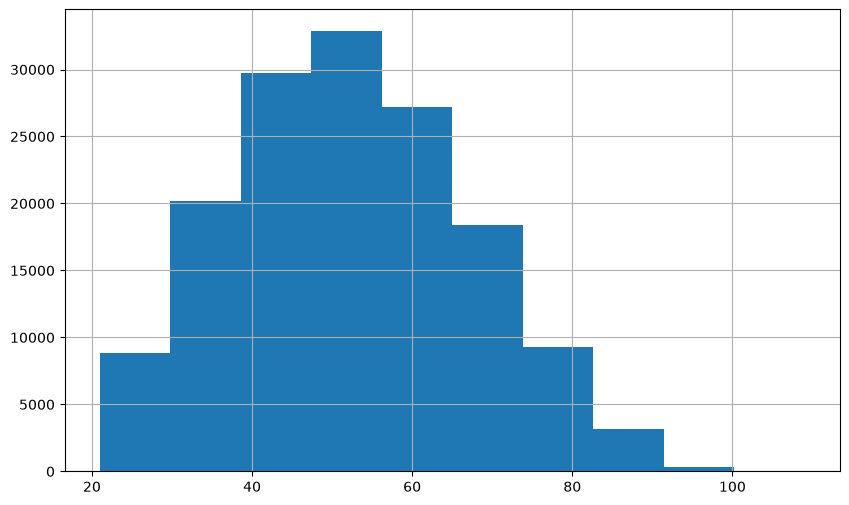

In [52]:
df_raw['idade'].hist()

## 4.4 atrasos_30_59_dias

In [54]:
df_raw['atrasos_30_59_dias'].value_counts()

atrasos_30_59_dias
0     126018
1      16032
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

- variável apresenta quantidade de vezes em que ocorreu esse tipo de atraso.
- 98 e 96 parecem flags.
- espera-se que pessoas que possuam poucos atrasos nesse intervalo não seja inadimplente.

## 4.5 atrasos_60_89_dias

In [57]:
df_raw['atrasos_60_89_dias'].value_counts()

atrasos_60_89_dias
0     142395
1       5731
2       1118
3        318
98       264
4        105
5         34
6         16
7          9
96         5
8          2
11         1
9          1
Name: count, dtype: int64

- variável apresenta quantidade de vezes em que ocorreu esse tipo de atraso.
- 98 e 96 parecem flags.
- espera-se que pessoas que possuam poucos atrasos nesse intervalo não seja inadimplente.

## 4.6 atrasos_90_dias_ou_mais

In [58]:
df_raw['atrasos_90_dias_ou_mais'].value_counts()

atrasos_90_dias_ou_mais
0     141661
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

- variável apresenta quantidade de vezes em que ocorreu esse tipo de atraso.
- 98 e 96 parecem flags.
- espera-se que pessoas que possuam poucos atrasos nesse intervalo não seja inadimplente.

## 4.7 indice_endividamento

<Axes: >

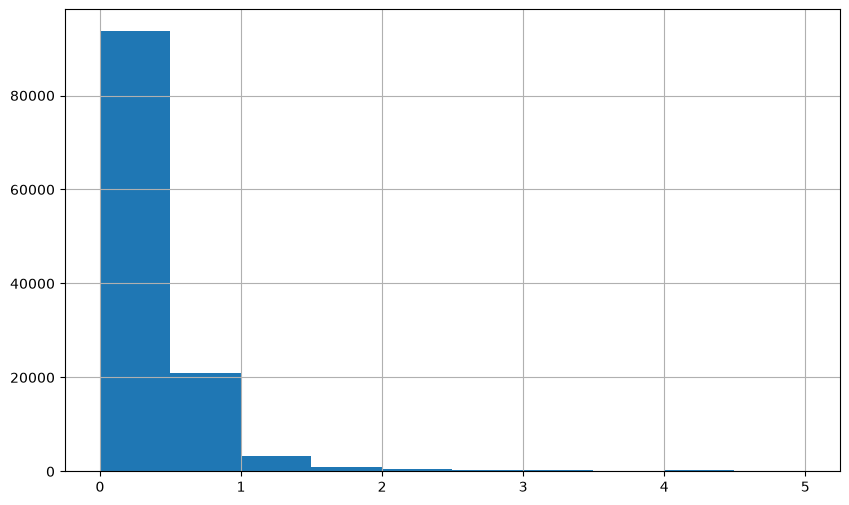

In [78]:
df_raw[df_raw['indice_endividamento'] < 5]['indice_endividamento'].hist()

In [ ]:
df_raw[df_raw['indice_endividamento'] >= 5]['indice_endividamento'].shape

(29789,)

- indice maior que 5 possui muitos registros: 29789/150000

## 4.8 renda_mensal

<Axes: >

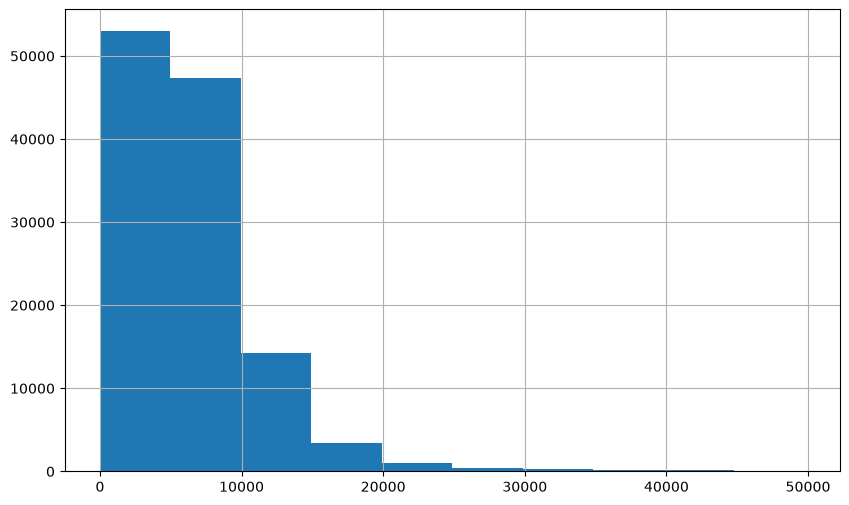

In [81]:
df_raw[df_raw['renda_mensal'] < 5e4]['renda_mensal'].hist()

In [82]:
df_raw[df_raw['renda_mensal'] >= 5e4]['renda_mensal'].shape

(321,)

In [94]:
df_raw[df_raw['renda_mensal'].isna()]['renda_mensal'].shape

(29731,)

- acima de U$50000 poucos registros: 321/150000
- possui muitos valores nans: 29731/150000

## 4.9 num_linhas_credito

<Axes: >

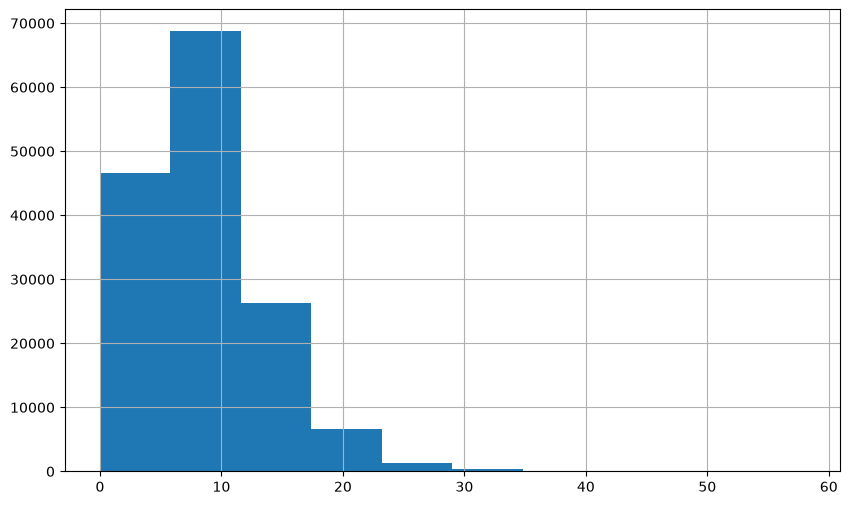

In [84]:
df_raw['num_linhas_credito'].hist()

- o que significa?
- quanto maior esse valor significa que a pessoa tem mais cartões, por exemplo?

## 4.10 num_emprestimos_imobiliarios

<Axes: >

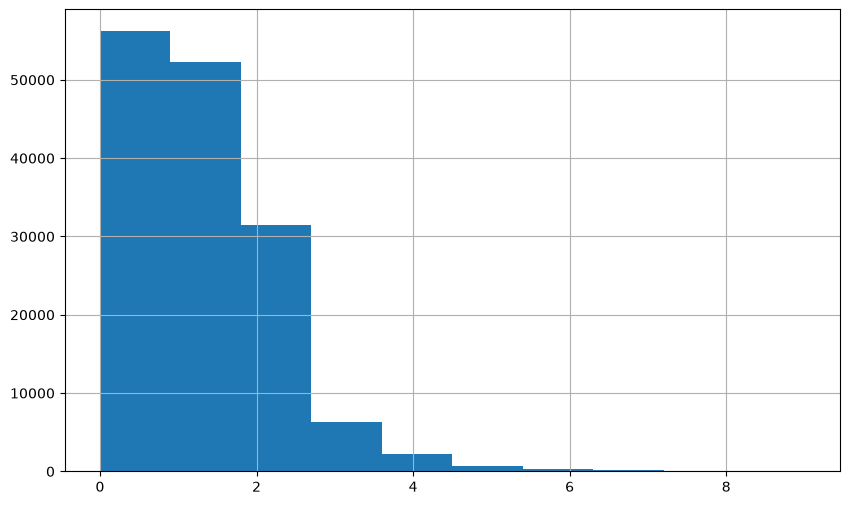

In [89]:
df_raw[df_raw['num_emprestimos_imobiliarios'] < 10]['num_emprestimos_imobiliarios'].hist()

In [90]:
df_raw[df_raw['num_emprestimos_imobiliarios'] >= 10]['num_emprestimos_imobiliarios'].shape

(131,)

- poucos registros com num_emprestimos_imobiliarios acima de 10: 131/150000

## 4.11 num_dependentes

In [91]:
df_raw['num_dependentes'].value_counts()

num_dependentes
0.00     86902
1.00     26316
2.00     19521
3.00      9483
4.00      2862
5.00       746
6.00       158
7.00        51
8.00        24
10.00        5
9.00         5
20.00        1
13.00        1
Name: count, dtype: int64

In [95]:
df_raw[df_raw['num_dependentes'].isna()]['num_dependentes'].shape

(3924,)

- poucos valores nans: 3924/150000

# 5. Análise Exploratória

<Axes: >

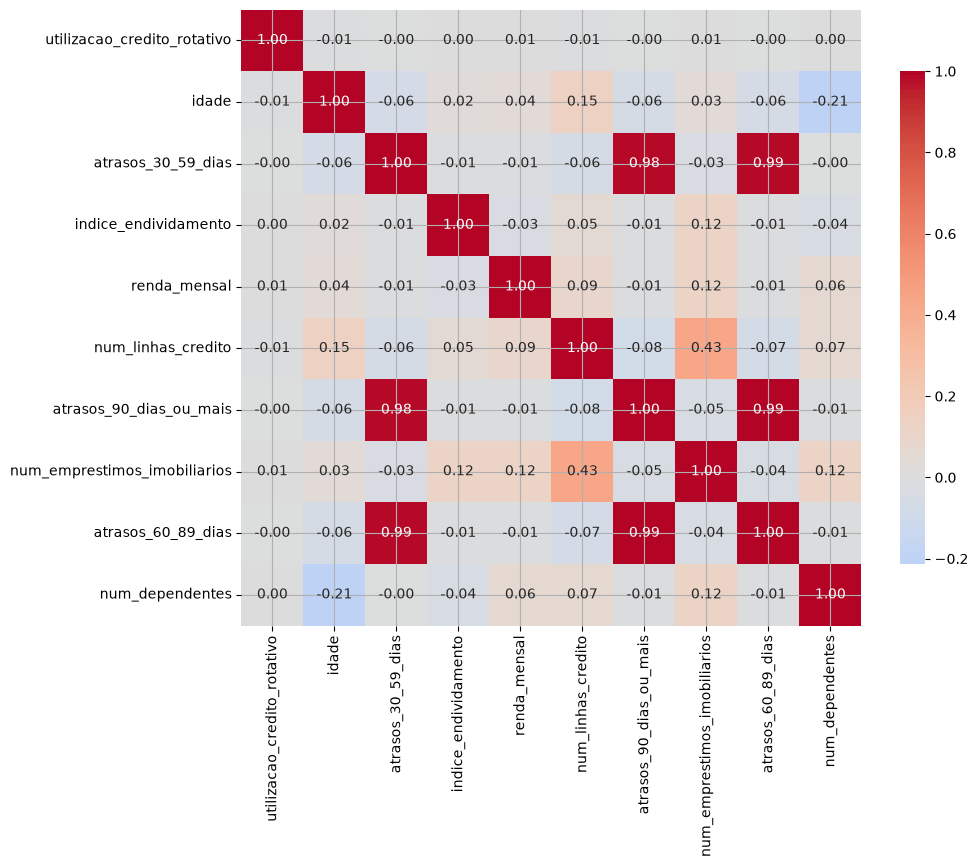

In [105]:
corr = df_raw.drop(columns=['id', 'inadimplente']).corr(numeric_only=True, method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"shrink": .8})

<Axes: >

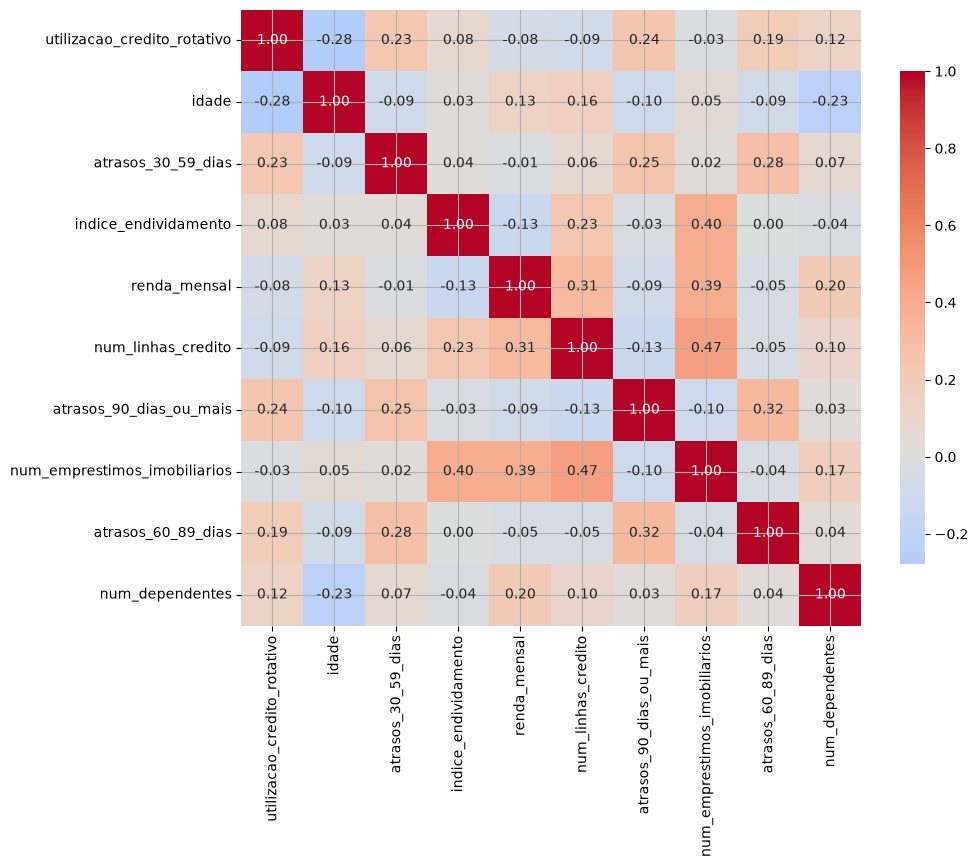

In [103]:
corr = df_raw.drop(columns=['id', 'inadimplente']).corr(numeric_only=True, method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"shrink": .8})

# 6. Análise das Features

In [107]:
target = "inadimplente"

features = [col for col in df_raw.columns if col != target and col != 'id']

In [111]:
df_raw.groupby(target)[features].agg(["mean", "median"]).T

inadimplente                              0       1
utilizacao_credito_rotativo  mean      6.17    4.37
                             median    0.13    0.84
idade                        mean     52.75   45.93
                             median   52.00   45.00
atrasos_30_59_dias           mean      0.28    2.39
                             median    0.00    0.00
indice_endividamento         mean    357.15  295.12
                             median    0.36    0.43
renda_mensal                 mean   6747.84 5630.83
                             median 5466.00 4500.00
num_linhas_credito           mean      8.49    7.88
                             median    8.00    7.00
atrasos_90_dias_ou_mais      mean      0.14    2.09
                             median    0.00    0.00
num_emprestimos_imobiliarios mean      1.02    0.99
                             median    1.00    1.00
atrasos_60_89_dias           mean      0.13    1.83
                             median    0.00    0.00
num_dependentes              mean      0.74    0.95
                             median    0.00    0.00

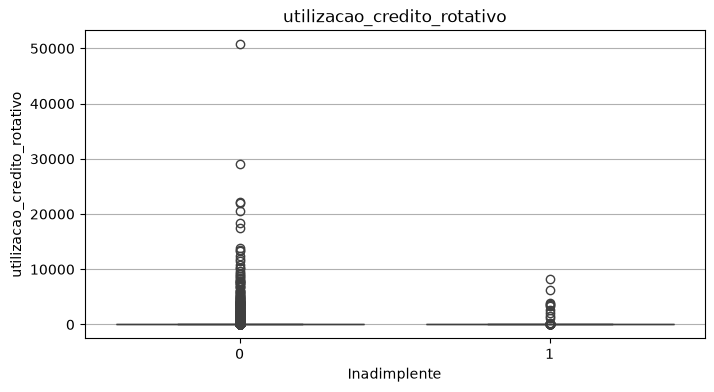

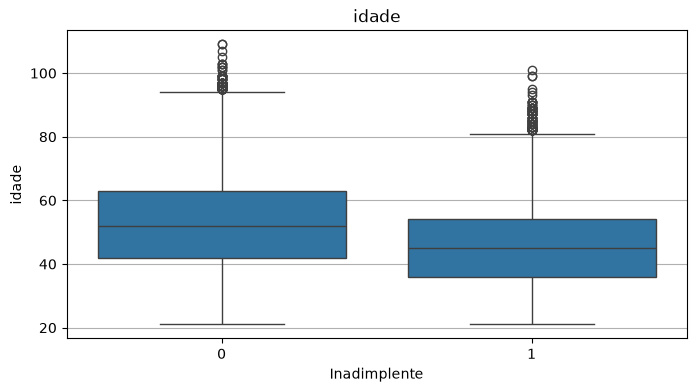

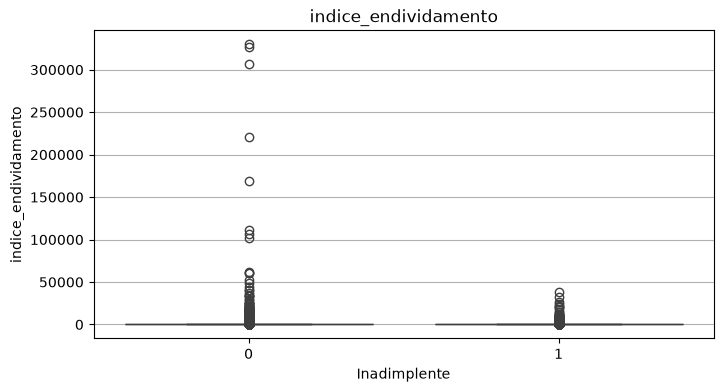

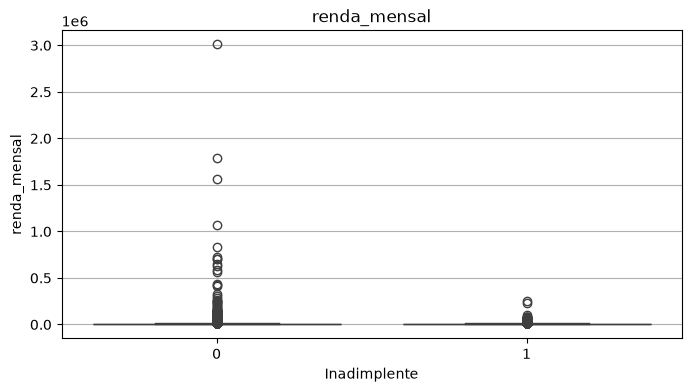

In [112]:
continuous_features = [
    "utilizacao_credito_rotativo",
    "idade",
    "indice_endividamento",
    "renda_mensal",
]

for feature in continuous_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df_raw,
        x=target,
        y=feature
    )

    plt.title(feature)
    plt.xlabel("Inadimplente")
    plt.ylabel(feature)

    plt.show()

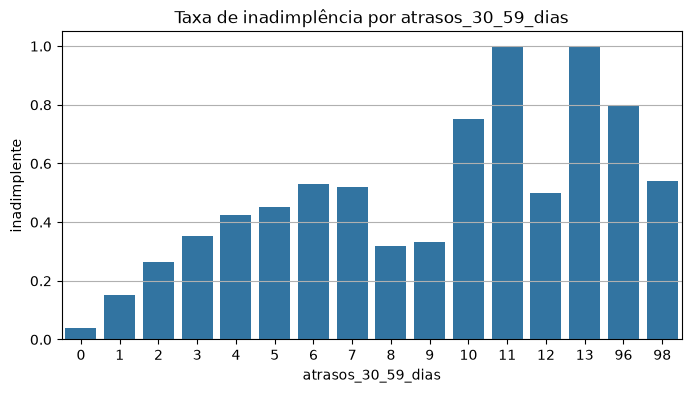

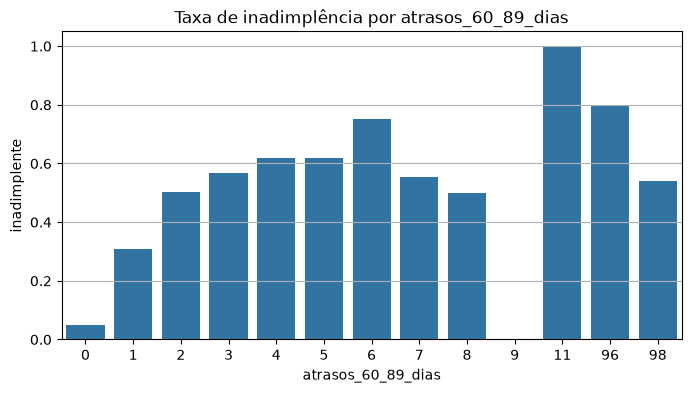

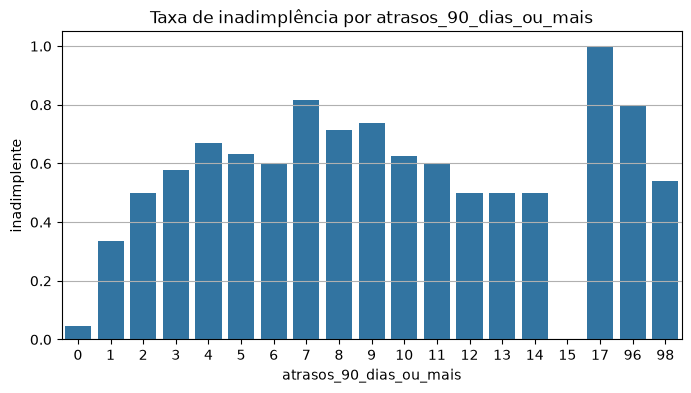

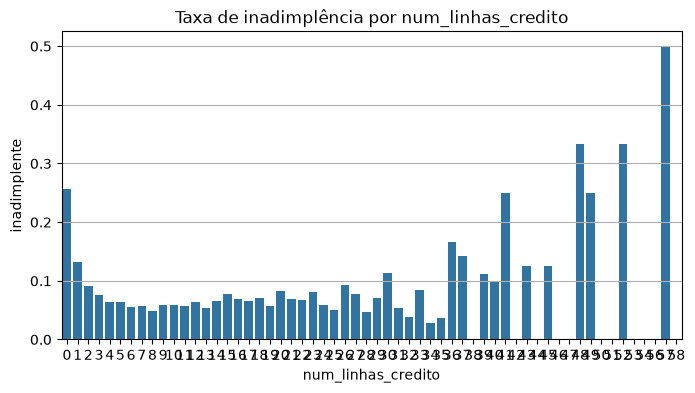

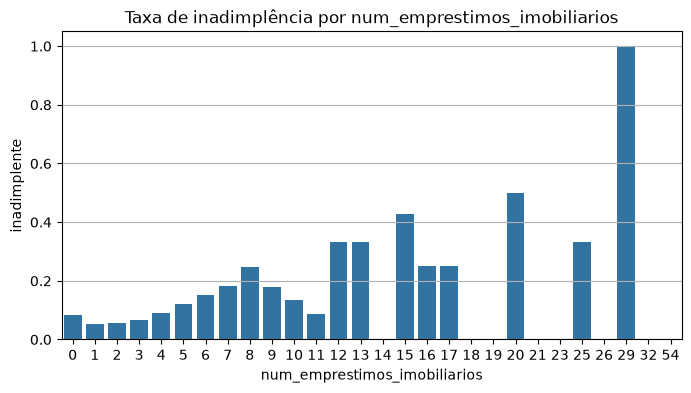

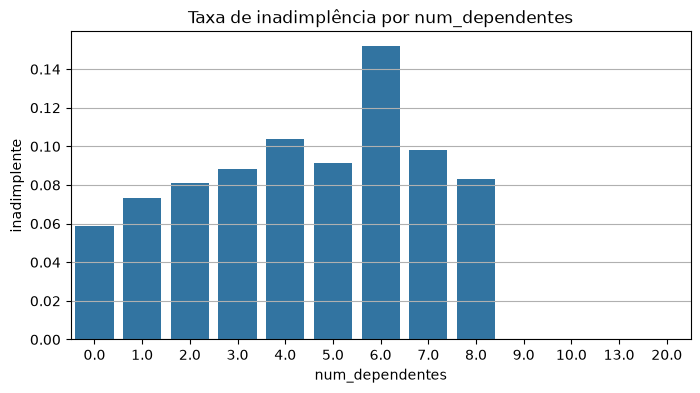

In [113]:
# ============================================================
# Taxa de inadimplência
# ============================================================

categorical_like = [
    "atrasos_30_59_dias",
    "atrasos_60_89_dias",
    "atrasos_90_dias_ou_mais",
    "num_linhas_credito",
    "num_emprestimos_imobiliarios",
    "num_dependentes",
]

for feature in categorical_like:

    taxa = (
        df_raw
        .groupby(feature)[target]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=taxa,
        x=feature,
        y=target
    )

    plt.title(f"Taxa de inadimplência por {feature}")

    plt.show()

In [115]:
# ============================================================
# Correlação com a variável alvo
# ============================================================

corr_target = (
    df_raw
    .corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

corr_target

inadimplente                    1.00
atrasos_30_59_dias              0.13
atrasos_90_dias_ou_mais         0.12
atrasos_60_89_dias              0.10
num_dependentes                 0.05
id                              0.00
utilizacao_credito_rotativo    -0.00
num_emprestimos_imobiliarios   -0.01
indice_endividamento           -0.01
renda_mensal                   -0.02
num_linhas_credito             -0.03
idade                          -0.12
Name: inadimplente, dtype: float64

In [120]:
# ============================================================
# Mutual Information
# ============================================================

from sklearn.feature_selection import mutual_info_classif

X = df_raw.drop(columns=target)
y = df_raw[target]

mi = mutual_info_classif(
    X.fillna(-1),
    y,
    random_state=42,
    n_neighbors=5
)

mi = (
    pd.Series(
        mi,
        index=X.columns,
        name="Mutual Information"
    )
    .sort_values(ascending=False)
)

mi

utilizacao_credito_rotativo    0.04
atrasos_90_dias_ou_mais        0.03
atrasos_30_59_dias             0.03
atrasos_60_89_dias             0.02
idade                          0.01
num_linhas_credito             0.00
indice_endividamento           0.00
num_emprestimos_imobiliarios   0.00
renda_mensal                   0.00
num_dependentes                0.00
id                             0.00
Name: Mutual Information, dtype: float64

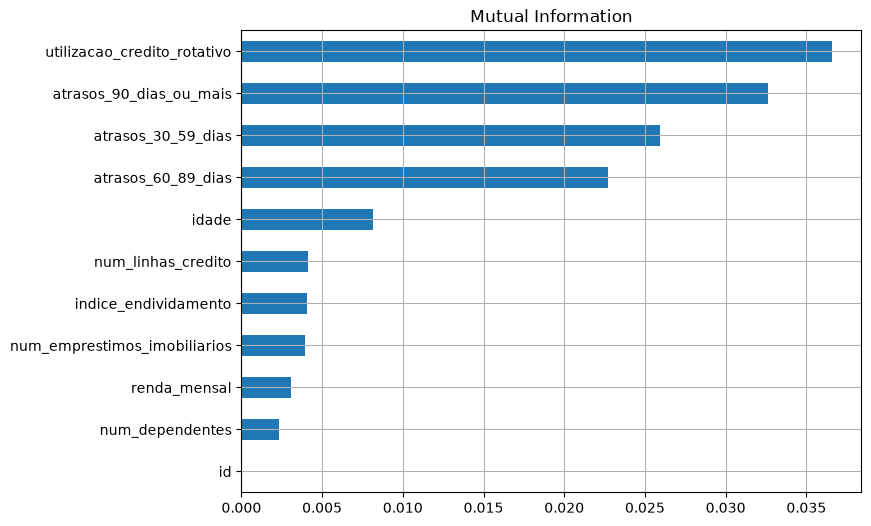

In [121]:
plt.figure(figsize=(8,6))

mi.sort_values().plot.barh()

plt.title("Mutual Information")

plt.show()

In [122]:
# ============================================================
# 7.8 KS Statistic por Feature
# ============================================================

from scipy.stats import ks_2samp

ks_results = []

for feature in X.columns:

    grupo_bom = df_raw.loc[df_raw[target] == 0, feature].dropna()
    grupo_mau = df_raw.loc[df_raw[target] == 1, feature].dropna()

    ks, pvalue = ks_2samp(grupo_bom, grupo_mau)

    ks_results.append({
        "Feature": feature,
        "KS": ks,
        "p-value": pvalue
    })

ks_df = (
    pd.DataFrame(ks_results)
      .sort_values("KS", ascending=False)
      .reset_index(drop=True)
)

ks_df

,Feature,KS,p-value
0,utilizacao_credito_rotativo,0.46,0.00
1,atrasos_30_59_dias,0.36,0.00
2,atrasos_90_dias_ou_mais,0.31,0.00
3,atrasos_60_89_dias,0.24,0.00
4,idade,0.21,0.00
5,renda_mensal,0.13,0.00
6,num_emprestimos_imobiliarios,0.10,0.00
7,num_linhas_credito,0.09,0.00
8,num_dependentes,0.08,0.00
9,indice_endividamento,0.07,0.00


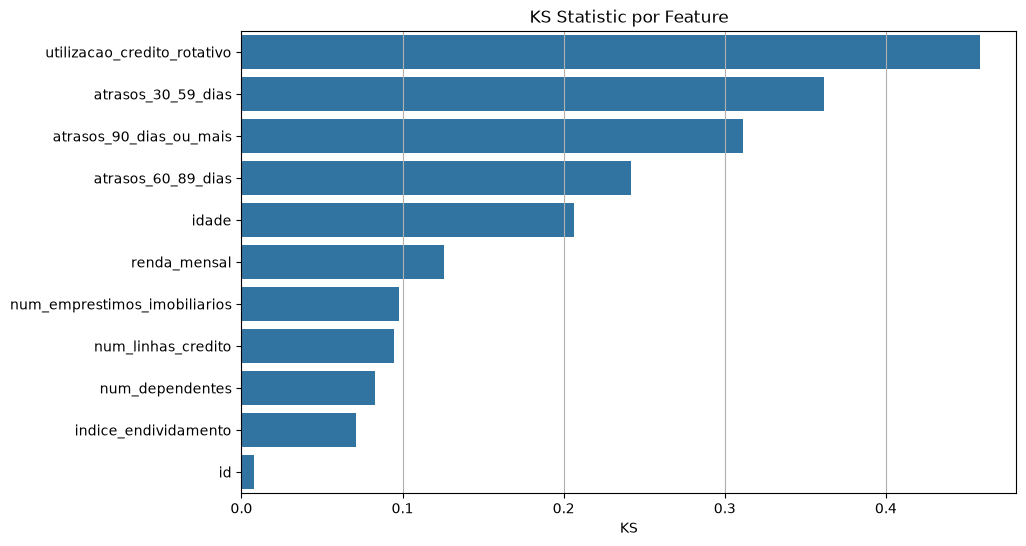

In [123]:
# ============================================================
# Visualização do KS
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=ks_df,
    x="KS",
    y="Feature"
)

plt.title("KS Statistic por Feature")
plt.xlabel("KS")
plt.ylabel("")

plt.show()

# 7. Relação entre Features e Target

# 8. Qualidade dos Dados

# 9. Hipóteses e Insights